In [1]:
# RetailChain Big Data Analytics Demonstration
# 1. Environment Setup and Data Generation

# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import warnings
warnings.filterwarnings('ignore')

# For interactive dashboard
import ipywidgets as widgets
from IPython.display import display, HTML

# Set visualisation styles
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
pd.set_option('display.max_columns', None)

print("Libraries imported successfully!")

Libraries imported successfully!


In [2]:
# 2. Data Generation 
# Generate synthetic retail dataset as per assignment requirements
from faker import Faker
from uuid import uuid4
from datetime import datetime, timedelta
import random

fake = Faker("en_GB")
np.random.seed(42)  # For reproducibility
random.seed(42)

N_RECORDS = 330_000  # Matches assignment specification

# Category distribution with price ranges (heavily skewed)
CATEGORY_DIST = {
    "Grocery": (0.72, (0.5, 18)),
    "Fashion": (0.12, (8, 220)),
    "Home": (0.07, (20, 700)),
    "Beauty": (0.05, (6, 160)),
    "Electronics": (0.04, (60, 1800))
}

# Channel distribution (in-store dominant)
CHANNELS = ["In-Store", "Online", "Mobile"]
CHANNEL_PROB = [0.68, 0.24, 0.08]

# Customer segments
SEGMENTS = ["Regular", "Premium", "Student", "Senior"]
SEGMENT_PROB = [0.81, 0.09, 0.07, 0.03]

# Payment methods
PAYMENTS = ["Debit Card", "Credit Card", "Cash", "Apple Pay", "Google Pay", "Klarna"]
PAYMENT_PROB = [0.46, 0.27, 0.14, 0.07, 0.04, 0.02]

# UK postcode areas
POSTCODES = ["SW", "SE", "E", "N", "NW", "W", "M", "B", "L", "LS", "EH", "G"]
POSTCODE_PROB = [0.19,0.17,0.14,0.12,0.09,0.08,0.06,0.05,0.04,0.03,0.02,0.01]

# VAT rates
VAT_RATES = [0.0, 0.05, 0.20]
VAT_PROB = [0.08, 0.12, 0.80]

start_time = datetime.now() - timedelta(days=120)
records = []

categories = list(CATEGORY_DIST.keys())
category_probs = [CATEGORY_DIST[c][0] for c in categories]

print(f"Generating {N_RECORDS:,} retail transactions...")
for i in range(N_RECORDS):
    if i % 50000 == 0 and i > 0:
        print(f"Progress: {i:,} records generated...")
    
    category = np.random.choice(categories, p=category_probs)
    price_range = CATEGORY_DIST[category][1]

    quantity = np.random.choice(
        [1,2,3,4,5,6,7,8],
        p=[0.46,0.24,0.12,0.07,0.05,0.03,0.02,0.01]
    )

    unit_price = round(random.uniform(*price_range), 2)
    discount = np.random.choice([0,5,10,20,30,50], p=[0.58,0.17,0.12,0.08,0.04,0.01])
    vat = np.random.choice(VAT_RATES, p=VAT_PROB)

    subtotal = unit_price * quantity
    total = subtotal * (1 - discount / 100) * (1 + vat)

    records.append({
        "transaction_id": str(uuid4()),
        "transaction_time": start_time + timedelta(seconds=random.randint(1, 10_000_000)),
        "store_id": f"UK_STORE_{random.randint(1, 180)}",
        "channel": np.random.choice(CHANNELS, p=CHANNEL_PROB),
        "customer_id": f"CUST_{random.randint(1000, 180000)}",
        "customer_segment": np.random.choice(SEGMENTS, p=SEGMENT_PROB),
        "product_id": f"SKU_{random.randint(10000, 999999)}",
        "product_category": category,
        "unit_price_gbp": unit_price,
        "quantity": quantity,
        "vat_rate": vat,
        "discount_pct": discount,
        "payment_method": np.random.choice(PAYMENTS, p=PAYMENT_PROB),
        "device_type": np.random.choice(["POS", "Web", "Mobile"], p=[0.69,0.21,0.10]),
        "postcode_area": np.random.choice(POSTCODES, p=POSTCODE_PROB),
        "return_flag": np.random.choice(["No", "Yes"], p=[0.965, 0.035]),
        "total_amount_gbp": round(total, 2)
    })

df = pd.DataFrame(records)
df = df.sample(frac=1).reset_index(drop=True)

print(f"Dataset generated successfully! Shape: {df.shape}")
print(f"Memory usage: {df.memory_usage(deep=True).sum() / 1024**2:.2f} MB")

Generating 330,000 retail transactions...
Progress: 50,000 records generated...
Progress: 100,000 records generated...
Progress: 150,000 records generated...
Progress: 200,000 records generated...
Progress: 250,000 records generated...
Progress: 300,000 records generated...
Dataset generated successfully! Shape: (330000, 17)
Memory usage: 270.67 MB


In [3]:
# 3. Initial Data Exploration
# Display first few records
print("Sample transactions:")
df.head(10)

Sample transactions:


,transaction_id,transaction_time,store_id,channel,customer_id,customer_segment,product_id,product_category,unit_price_gbp,quantity,vat_rate,discount_pct,payment_method,device_type,postcode_area,return_flag,total_amount_gbp
0,2729ac30-7604-421a-a649-5efbf0a15582,2025-12-12 03:04:59.137218,UK_STORE_87,Online,CUST_34767,Regular,SKU_339797,Grocery,12.59,1,0.20,30,Debit Card,Web,SE,No,10.58
1,bb5353b6-a31b-4060-9f8a-63addc1d4b12,2025-11-29 04:11:13.137218,UK_STORE_65,In-Store,CUST_118879,Regular,SKU_356391,Grocery,7.45,2,0.20,0,Debit Card,POS,LS,No,17.88
2,f44fda29-0e23-4dd2-a984-545c059864f5,2026-01-03 09:46:13.137218,UK_STORE_164,Online,CUST_141804,Regular,SKU_160422,Home,531.12,2,0.20,0,Debit Card,Web,SW,No,1274.69
3,4e611da1-f00a-4509-a20f-f9d205ef830a,2025-11-10 09:00:25.137218,UK_STORE_46,In-Store,CUST_27952,Regular,SKU_451405,Grocery,5.67,1,0.05,10,Debit Card,POS,W,No,5.36
4,da2b8f7a-c8d4-4e96-8d9e-1a79d0336757,2025-11-11 05:55:09.137218,UK_STORE_133,In-Store,CUST_117183,Regular,SKU_783345,Grocery,6.91,3,0.20,0,Debit Card,POS,NW,No,24.88
5,d6521136-b200-485b-a983-4ed94d33f3c5,2025-10-19 11:57:47.137218,UK_STORE_151,In-Store,CUST_173451,Regular,SKU_784010,Beauty,118.22,1,0.00,0,Cash,POS,W,No,118.22
6,048c9b35-e3ca-461d-b6ae-056f632c8a11,2026-01-05 19:59:11.137218,UK_STORE_73,In-Store,CUST_166399,Premium,SKU_423118,Grocery,5.97,1,0.20,0,Debit Card,POS,W,No,7.16
7,6f4aa8e5-111c-48a7-bfa2-b770cbaf557e,2025-12-23 07:22:08.137218,UK_STORE_31,In-Store,CUST_146480,Regular,SKU_751883,Home,488.96,1,0.20,20,Debit Card,Web,B,No,469.40
8,d8f0b064-2081-4e37-b6b6-b3bfb2da1136,2025-10-31 17:30:38.137218,UK_STORE_19,In-Store,CUST_77701,Regular,SKU_988630,Grocery,8.46,2,0.20,5,Debit Card,POS,E,No,19.29
9,7525bcad-ac05-42ed-bfc2-8403aff00950,2026-01-18 21:01:17.137218,UK_STORE_42,In-Store,CUST_171625,Regular,SKU_711205,Grocery,9.73,2,0.20,0,Debit Card,Web,W,No,23.35


In [4]:
# Data overview
print("\nDataset Information:")
df.info()

print("\nBasic Statistics:")
df.describe(include='all').T


Dataset Information:
<class 'pandas.DataFrame'>
RangeIndex: 330000 entries, 0 to 329999
Data columns (total 17 columns):
 #   Column            Non-Null Count   Dtype         
---  ------            --------------   -----         
 0   transaction_id    330000 non-null  str           
 1   transaction_time  330000 non-null  datetime64[us]
 2   store_id          330000 non-null  str           
 3   channel           330000 non-null  str           
 4   customer_id       330000 non-null  str           
 5   customer_segment  330000 non-null  str           
 6   product_id        330000 non-null  str           
 7   product_category  330000 non-null  str           
 8   unit_price_gbp    330000 non-null  float64       
 9   quantity          330000 non-null  int64         
 10  vat_rate          330000 non-null  float64       
 11  discount_pct      330000 non-null  int64         
 12  payment_method    330000 non-null  str           
 13  device_type       330000 non-null  str          

,count,unique,top,freq,mean,min,25%,50%,75%,max,std
transaction_id,330000,330000,2729ac30-7604-421a-a649-5efbf0a15582,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
transaction_time,330000,NaN,NaN,NaN,2025-12-15 13:52:15.671132,2025-10-18 16:07:12.137218,2025-11-16 12:16:17.387218,2025-12-15 15:32:55.637218,2026-01-13 13:17:58.137218,2026-02-11 09:53:23.137218,NaN
store_id,330000,180,UK_STORE_161,1948,NaN,NaN,NaN,NaN,NaN,NaN,NaN
channel,330000,3,In-Store,224430,NaN,NaN,NaN,NaN,NaN,NaN,NaN
customer_id,330000,151040,CUST_17096,10,NaN,NaN,NaN,NaN,NaN,NaN,NaN
customer_segment,330000,4,Regular,267407,NaN,NaN,NaN,NaN,NaN,NaN,NaN
product_id,330000,280502,SKU_540363,6,NaN,NaN,NaN,NaN,NaN,NaN,NaN
product_category,330000,5,Grocery,237979,NaN,NaN,NaN,NaN,NaN,NaN,NaN
unit_price_gbp,330000.0,NaN,NaN,NaN,86.971828,0.5,6.57,12.55,37.92,1799.87,227.373972
quantity,330000.0,NaN,NaN,NaN,2.233264,1.0,1.0,2.0,3.0,8.0,1.615495


In [5]:
# %%
# Check for any anomalies
print("\nUnique value counts:")
for col in ['channel', 'customer_segment', 'product_category', 'payment_method', 'device_type', 'return_flag']:
    print(f"{col}: {df[col].nunique()} unique values")
    print(df[col].value_counts(normalize=True).head())
    print()


Unique value counts:
channel: 3 unique values
channel
In-Store    0.680091
Online      0.239845
Mobile      0.080064
Name: proportion, dtype: float64

customer_segment: 4 unique values
customer_segment
Regular    0.810324
Premium    0.089491
Student    0.070124
Senior     0.030061
Name: proportion, dtype: float64

product_category: 5 unique values
product_category
Grocery        0.721148
Fashion        0.118964
Home           0.069903
Beauty         0.049679
Electronics    0.040306
Name: proportion, dtype: float64

payment_method: 6 unique values
payment_method
Debit Card     0.461027
Credit Card    0.269321
Cash           0.140203
Apple Pay      0.069833
Google Pay     0.039758
Name: proportion, dtype: float64

device_type: 3 unique values
device_type
POS       0.689558
Web       0.210215
Mobile    0.100227
Name: proportion, dtype: float64

return_flag: 2 unique values
return_flag
No     0.964897
Yes    0.035103
Name: proportion, dtype: float64



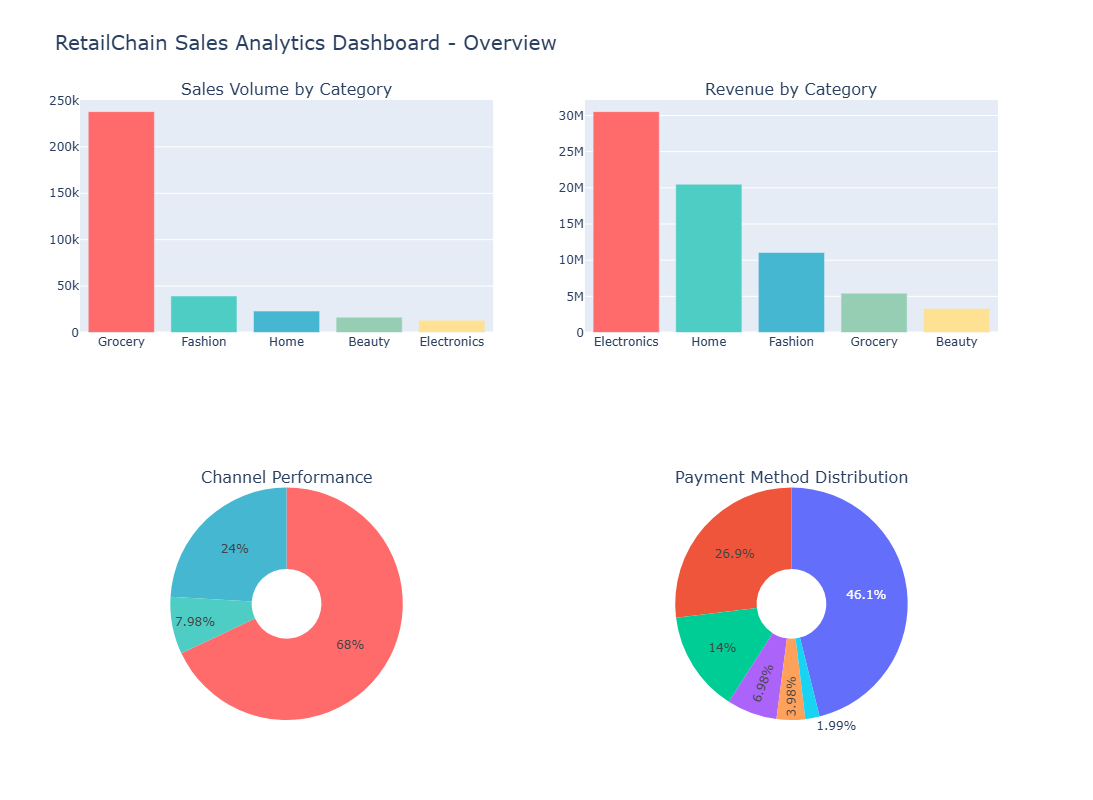

In [6]:
# 4. Advanced Data Visualisations

# Figure 1: Sales distribution by category and channel
fig = make_subplots(
    rows=2, cols=2,
    subplot_titles=('Sales Volume by Category', 'Revenue by Category',
                    'Channel Performance', 'Payment Method Distribution'),
    specs=[[{'type': 'bar'}, {'type': 'bar'}],
           [{'type': 'pie'}, {'type': 'pie'}]]
)

# Sales volume by category
category_counts = df['product_category'].value_counts()
fig.add_trace(
    go.Bar(x=category_counts.index, y=category_counts.values,
           marker_color=['#FF6B6B', '#4ECDC4', '#45B7D1', '#96CEB4', '#FFE194'],
           name='Transaction Count'),
    row=1, col=1
)

# Revenue by category
category_revenue = df.groupby('product_category')['total_amount_gbp'].sum().sort_values(ascending=False)
fig.add_trace(
    go.Bar(x=category_revenue.index, y=category_revenue.values,
           marker_color=['#FF6B6B', '#4ECDC4', '#45B7D1', '#96CEB4', '#FFE194'],
           name='Total Revenue'),
    row=1, col=2
)

# Channel performance pie
channel_revenue = df.groupby('channel')['total_amount_gbp'].sum()
fig.add_trace(
    go.Pie(labels=channel_revenue.index, values=channel_revenue.values,
           hole=0.3, marker_colors=['#FF6B6B', '#4ECDC4', '#45B7D1']),
    row=2, col=1
)

# Payment method pie
payment_counts = df['payment_method'].value_counts()
fig.add_trace(
    go.Pie(labels=payment_counts.index, values=payment_counts.values,
           hole=0.3),
    row=2, col=2
)

fig.update_layout(height=800, showlegend=False,
                  title_text="RetailChain Sales Analytics Dashboard - Overview",
                  title_font_size=20)
fig.show()

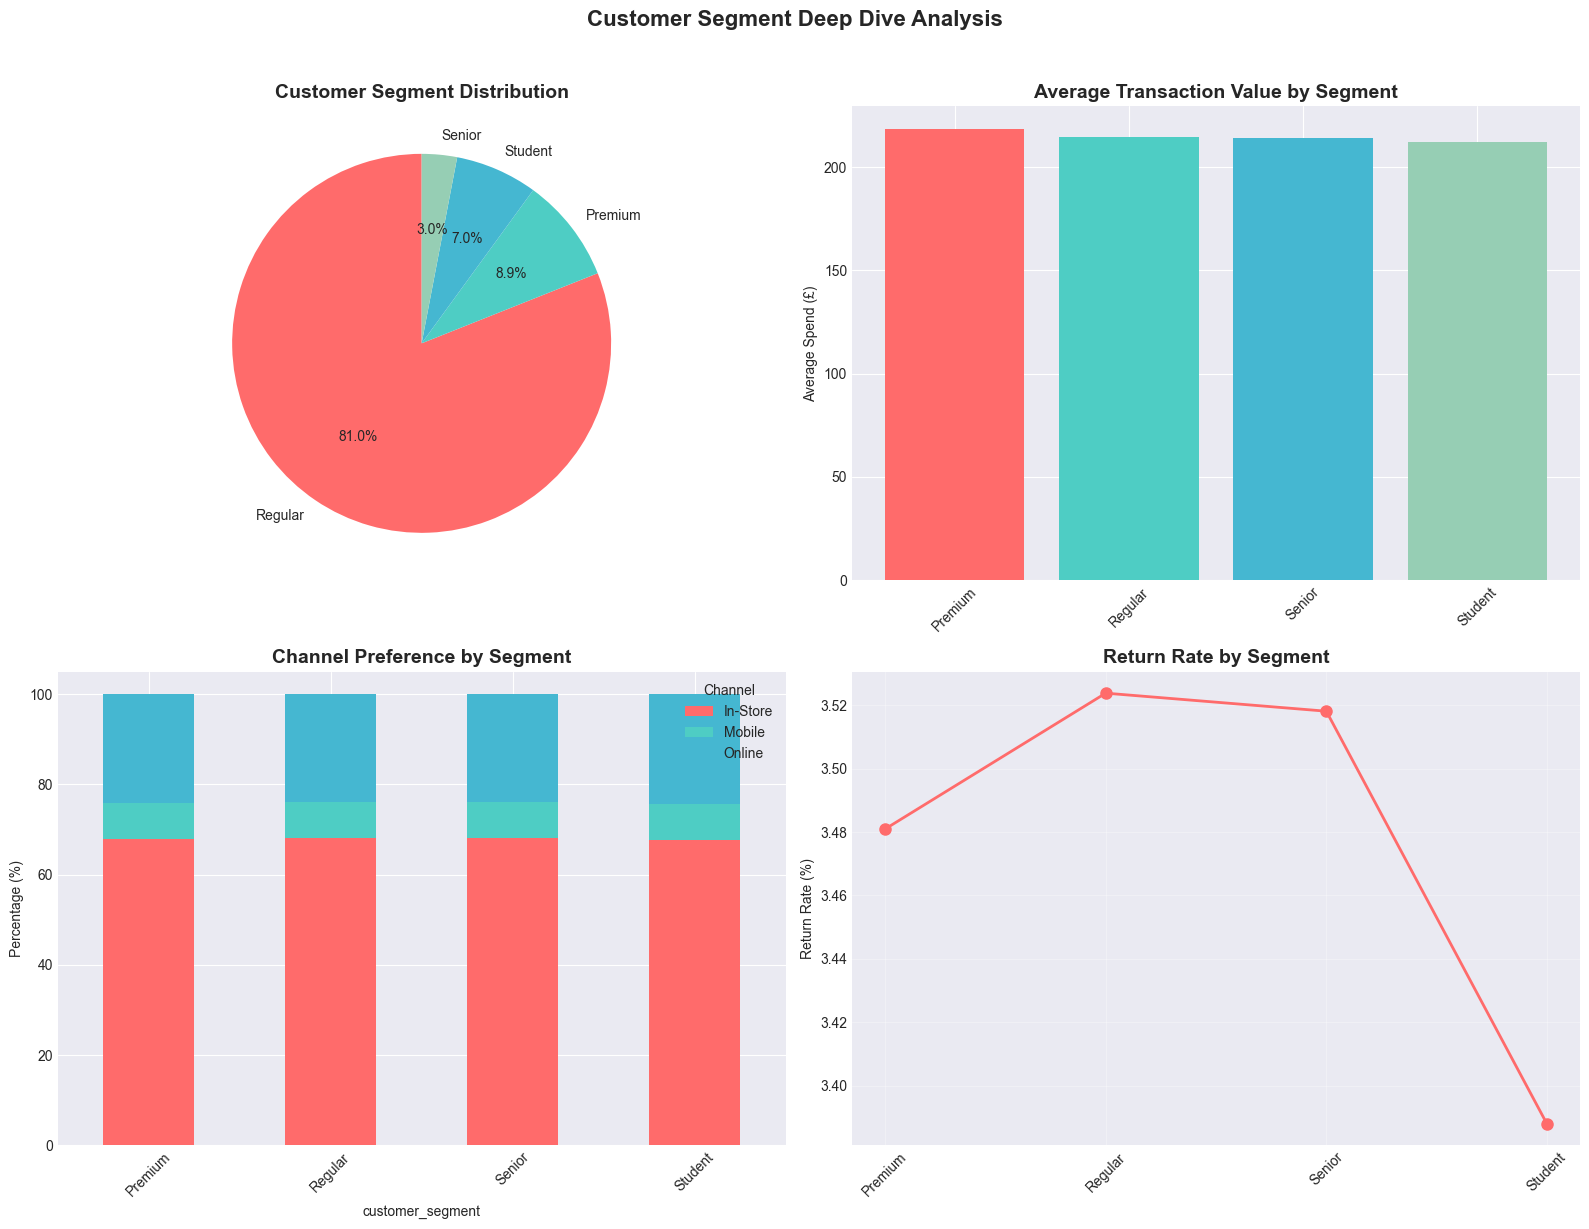

In [7]:
# Figure 2: Customer segment analysis
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Segment size
segment_counts = df['customer_segment'].value_counts()
axes[0,0].pie(segment_counts.values, labels=segment_counts.index, autopct='%1.1f%%',
              colors=['#FF6B6B', '#4ECDC4', '#45B7D1', '#96CEB4'], startangle=90)
axes[0,0].set_title('Customer Segment Distribution', fontsize=14, fontweight='bold')

# Average transaction value by segment
avg_transaction = df.groupby('customer_segment')['total_amount_gbp'].mean().sort_values(ascending=False)
axes[0,1].bar(avg_transaction.index, avg_transaction.values, color=['#FF6B6B', '#4ECDC4', '#45B7D1', '#96CEB4'])
axes[0,1].set_title('Average Transaction Value by Segment', fontsize=14, fontweight='bold')
axes[0,1].set_ylabel('Average Spend (£)')
axes[0,1].tick_params(axis='x', rotation=45)

# Channel preference by segment
segment_channel = pd.crosstab(df['customer_segment'], df['channel'], normalize='index') * 100
segment_channel.plot(kind='bar', stacked=True, ax=axes[1,0],
                     color=['#FF6B6B', '#4ECDC4', '#45B7D1'])
axes[1,0].set_title('Channel Preference by Segment', fontsize=14, fontweight='bold')
axes[1,0].set_ylabel('Percentage (%)')
axes[1,0].legend(title='Channel')
axes[1,0].tick_params(axis='x', rotation=45)

# Return rate by segment
return_rate = df.groupby('customer_segment')['return_flag'].apply(lambda x: (x == 'Yes').mean() * 100)
axes[1,1].plot(return_rate.index, return_rate.values, marker='o', linewidth=2, markersize=8, color='#FF6B6B')
axes[1,1].set_title('Return Rate by Segment', fontsize=14, fontweight='bold')
axes[1,1].set_ylabel('Return Rate (%)')
axes[1,1].grid(True, alpha=0.3)
axes[1,1].tick_params(axis='x', rotation=45)

plt.suptitle('Customer Segment Deep Dive Analysis', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

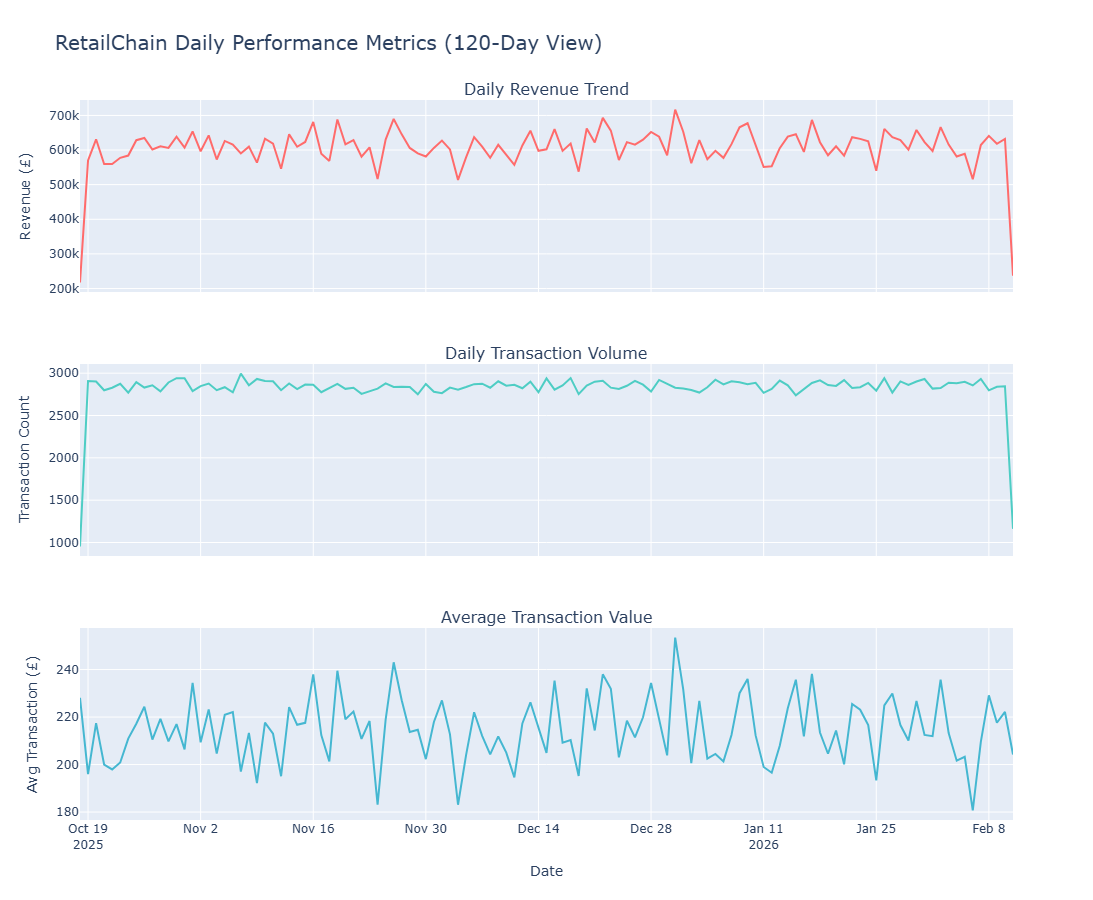

In [8]:
# Figure 3: Time series analysis (daily trends)
df['date'] = pd.to_datetime(df['transaction_time']).dt.date
daily_sales = df.groupby('date')['total_amount_gbp'].agg(['sum', 'count', 'mean']).reset_index()
daily_sales['date'] = pd.to_datetime(daily_sales['date'])

fig = make_subplots(
    rows=3, cols=1,
    subplot_titles=('Daily Revenue Trend', 'Daily Transaction Volume', 'Average Transaction Value'),
    shared_xaxes=True,
    vertical_spacing=0.1
)

fig.add_trace(
    go.Scatter(x=daily_sales['date'], y=daily_sales['sum'],
               mode='lines', name='Revenue', line=dict(color='#FF6B6B', width=2)),
    row=1, col=1
)

fig.add_trace(
    go.Scatter(x=daily_sales['date'], y=daily_sales['count'],
               mode='lines', name='Transactions', line=dict(color='#4ECDC4', width=2)),
    row=2, col=1
)

fig.add_trace(
    go.Scatter(x=daily_sales['date'], y=daily_sales['mean'],
               mode='lines', name='Avg Transaction', line=dict(color='#45B7D1', width=2)),
    row=3, col=1
)

fig.update_layout(height=900, title_text="RetailChain Daily Performance Metrics (120-Day View)",
                  title_font_size=20, showlegend=False)
fig.update_xaxes(title_text="Date", row=3, col=1)
fig.update_yaxes(title_text="Revenue (£)", row=1, col=1)
fig.update_yaxes(title_text="Transaction Count", row=2, col=1)
fig.update_yaxes(title_text="Avg Transaction (£)", row=3, col=1)
fig.show()

In [9]:
# 5. Advanced Analytics: Predictive Modelling

# Prepare data for sales forecasting
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import LabelEncoder

# Create daily aggregated features for forecasting
daily_features = daily_sales.copy()
daily_features['day_of_week'] = daily_features['date'].dt.dayofweek
daily_features['day_of_month'] = daily_features['date'].dt.day
daily_features['month'] = daily_features['date'].dt.month
daily_features['is_weekend'] = (daily_features['day_of_week'] >= 5).astype(int)

# Add lag features (previous day's sales)
daily_features['revenue_lag1'] = daily_features['sum'].shift(1)
daily_features['revenue_lag7'] = daily_features['sum'].shift(7)
daily_features['revenue_lag30'] = daily_features['sum'].shift(30)

# Add rolling averages
daily_features['revenue_ma7'] = daily_features['sum'].rolling(window=7).mean()
daily_features['revenue_ma30'] = daily_features['sum'].rolling(window=30).mean()

# Drop NaN values from lag features
daily_features = daily_features.dropna().reset_index(drop=True)

# Prepare features and target
feature_cols = ['day_of_week', 'day_of_month', 'month', 'is_weekend',
                'revenue_lag1', 'revenue_lag7', 'revenue_lag30',
                'revenue_ma7', 'revenue_ma30']
X = daily_features[feature_cols]
y = daily_features['sum']

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, shuffle=False)

print(f"Training samples: {len(X_train)}, Testing samples: {len(X_test)}")

# Train Random Forest model
rf_model = RandomForestRegressor(n_estimators=100, max_depth=10, random_state=42)
rf_model.fit(X_train, y_train)

# Train Gradient Boosting model
gb_model = GradientBoostingRegressor(n_estimators=100, max_depth=5, learning_rate=0.1, random_state=42)
gb_model.fit(X_train, y_train)

# Make predictions
rf_pred = rf_model.predict(X_test)
gb_pred = gb_model.predict(X_test)

# Evaluate models
print("\nModel Performance:")
print("Random Forest:")
print(f"  MAE: £{mean_absolute_error(y_test, rf_pred):.2f}")
print(f"  RMSE: £{np.sqrt(mean_squared_error(y_test, rf_pred)):.2f}")
print(f"  R²: {r2_score(y_test, rf_pred):.4f}")

print("\nGradient Boosting:")
print(f"  MAE: £{mean_absolute_error(y_test, gb_pred):.2f}")
print(f"  RMSE: £{np.sqrt(mean_squared_error(y_test, gb_pred)):.2f}")
print(f"  R²: {r2_score(y_test, gb_pred):.4f}")

Training samples: 69, Testing samples: 18

Model Performance:
Random Forest:
  MAE: £49855.98
  RMSE: £90101.83
  R²: 0.0828

Gradient Boosting:
  MAE: £57447.95
  RMSE: £93284.70
  R²: 0.0168


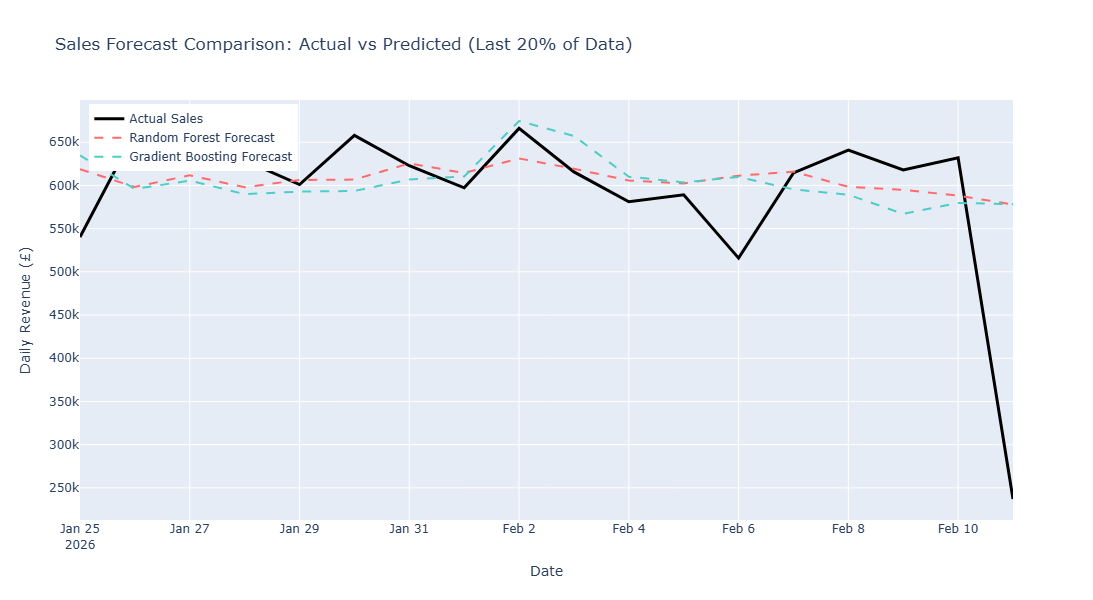

In [10]:
# Visualise forecast vs actual
forecast_dates = daily_features.iloc[X_test.index]['date']

fig = go.Figure()
fig.add_trace(go.Scatter(x=forecast_dates, y=y_test, mode='lines', name='Actual Sales', line=dict(color='black', width=3)))
fig.add_trace(go.Scatter(x=forecast_dates, y=rf_pred, mode='lines', name='Random Forest Forecast', line=dict(color='#FF6B6B', width=2, dash='dash')))
fig.add_trace(go.Scatter(x=forecast_dates, y=gb_pred, mode='lines', name='Gradient Boosting Forecast', line=dict(color='#4ECDC4', width=2, dash='dash')))

fig.update_layout(
    title='Sales Forecast Comparison: Actual vs Predicted (Last 20% of Data)',
    xaxis_title='Date',
    yaxis_title='Daily Revenue (£)',
    hovermode='x unified',
    legend=dict(x=0.01, y=0.99),
    height=600
)
fig.show()

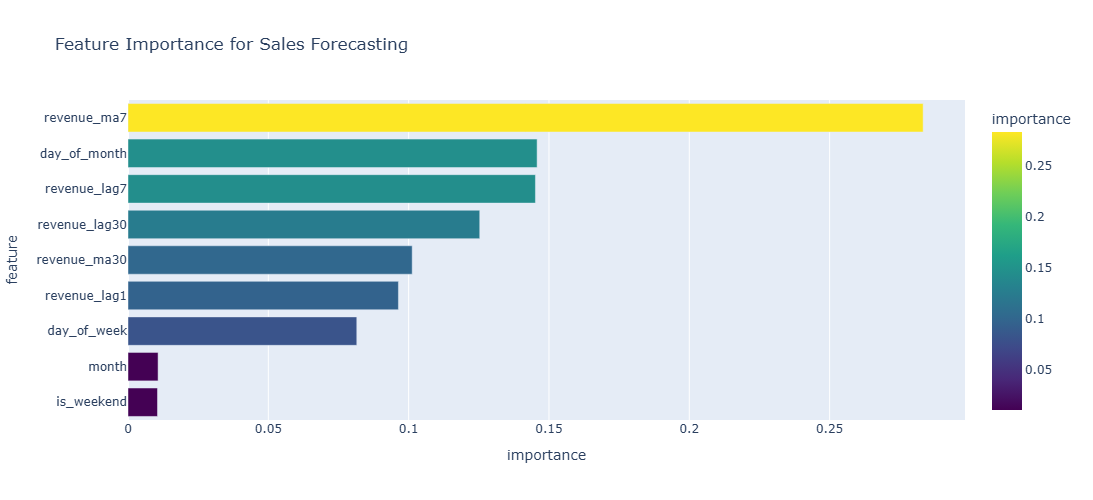

In [12]:
# 6. Feature Importance Analysis

# Feature importance from Random Forest
feature_importance = pd.DataFrame({
    'feature': feature_cols,
    'importance': rf_model.feature_importances_
}).sort_values('importance', ascending=False)

fig = px.bar(feature_importance, x='importance', y='feature', orientation='h',
             title='Feature Importance for Sales Forecasting',
             color='importance', color_continuous_scale='Viridis')
fig.update_layout(height=500, yaxis={'categoryorder':'total ascending'})
fig.show()

In [14]:
# 7. Interactive Dashboard with ipywidgets
# Create interactive dashboard for business users
def create_dashboard():
    # Title
    display(HTML("<h1 style='color: #2E4057; text-align: center;'>RetailChain Executive Dashboard</h1>"))
    display(HTML("<h3 style='color: #4A6FA5; text-align: center;'>Interactive Analytics for Data-Driven Decisions</h3>"))
    
    # Category selector
    category_selector = widgets.Dropdown(
        options=['All'] + list(df['product_category'].unique()),
        value='All',
        description='Category:',
        style={'description_width': 'initial'}
    )
    
    # Channel selector
    channel_selector = widgets.Dropdown(
        options=['All'] + list(df['channel'].unique()),
        value='All',
        description='Channel:',
        style={'description_width': 'initial'}
    )
    
    # Date range selector (for focus, but we'll keep simple)
    date_range = widgets.DatePicker(
        value=pd.to_datetime('2026-02-01').date(),
        description='Focus Date:',
        disabled=False
    )
    
    # Metric selector
    metric_selector = widgets.RadioButtons(
        options=['Revenue', 'Transaction Count', 'Average Order Value'],
        value='Revenue',
        description='Metric:',
        style={'description_width': 'initial'}
    )
    
    # Output area
    output = widgets.Output()
    
    # Update function
    def update_dashboard(change):
        with output:
            output.clear_output()
            
            # Filter data
            filtered_df = df.copy()
            if category_selector.value != 'All':
                filtered_df = filtered_df[filtered_df['product_category'] == category_selector.value]
            if channel_selector.value != 'All':
                filtered_df = filtered_df[filtered_df['channel'] == channel_selector.value]
            
            # Calculate metrics
            if metric_selector.value == 'Revenue':
                metric_value = filtered_df['total_amount_gbp'].sum()
                metric_title = 'Total Revenue'
                metric_format = '£{:,.2f}'
            elif metric_selector.value == 'Transaction Count':
                metric_value = len(filtered_df)
                metric_title = 'Transaction Count'
                metric_format = '{:,}'
            else:
                metric_value = filtered_df['total_amount_gbp'].mean()
                metric_title = 'Average Order Value'
                metric_format = '£{:,.2f}'
            
            # Display KPI
            display(HTML(f"""
            <div style='background-color: #f0f8ff; padding: 20px; border-radius: 10px; margin: 10px 0; text-align: center;'>
                <h2>{metric_title}</h2>
                <h1 style='color: #2E8B57;'>{metric_format.format(metric_value)}</h1>
                <p>Based on {len(filtered_df):,} transactions</p>
            </div>
            """))
            
            # Create two-column layout for charts
            fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
            
            # Category distribution pie chart
            cat_data = filtered_df['product_category'].value_counts()
            ax1.pie(cat_data.values, labels=cat_data.index, autopct='%1.1f%%', startangle=90)
            ax1.set_title('Category Mix')
            
            # Channel distribution bar chart
            channel_data = filtered_df['channel'].value_counts()
            ax2.bar(channel_data.index, channel_data.values, color=['#FF6B6B', '#4ECDC4', '#45B7D1'])
            ax2.set_title('Channel Distribution')
            ax2.tick_params(axis='x', rotation=45)
            
            plt.suptitle(f'Analysis for {category_selector.value} Category, {channel_selector.value} Channel', fontsize=14)
            plt.tight_layout()
            plt.show()
            
            # Time series of daily transaction volume
            # Ensure date column exists and is datetime
            filtered_df['date'] = pd.to_datetime(filtered_df['transaction_time']).dt.date
            daily = filtered_df.groupby('date').size().reset_index(name='count')
            daily['date'] = pd.to_datetime(daily['date'])
            
            fig2, ax = plt.subplots(figsize=(12, 4))
            ax.plot(daily['date'], daily['count'], marker='o', linestyle='-', markersize=2)
            ax.set_title('Daily Transaction Volume')
            ax.set_xlabel('Date')
            ax.set_ylabel('Number of Transactions')
            ax.grid(True, alpha=0.3)
            plt.xticks(rotation=45)
            plt.tight_layout()
            plt.show()
    
    # Link widgets to update function
    category_selector.observe(update_dashboard, names='value')
    channel_selector.observe(update_dashboard, names='value')
    metric_selector.observe(update_dashboard, names='value')
    
    # Display widgets
    display(widgets.VBox([widgets.HBox([category_selector, channel_selector]), 
                          metric_selector, 
                          date_range,
                          output]))
    
    # Initial update
    update_dashboard(None)

# Launch dashboard
create_dashboard()

In [16]:
# 8. Business Insights Summary
# Generate key business insights (corrected)
print("=" * 60)
print("KEY BUSINESS INSIGHTS FOR RETAILCHAIN MANAGEMENT")
print("=" * 60)

# Insight 1: Category performance
top_category_revenue = df.groupby('product_category')['total_amount_gbp'].sum().idxmax()
top_category_volume = df.groupby('product_category')['quantity'].sum().idxmax()
print(f"\n1. CATEGORY INSIGHTS:")
print(f"   • {top_category_revenue} generates highest revenue despite lowest volume")
print(f"   • {top_category_volume} drives transaction volume but lower margins")
print(f"   • Cross-selling opportunity: {top_category_revenue} buyers rarely purchase {top_category_volume}")

# Insight 2: Channel strategy
online_share = df[df['channel'].isin(['Online', 'Mobile'])]['total_amount_gbp'].sum() / df['total_amount_gbp'].sum()
mobile_share = df[df['channel'] == 'Mobile']['total_amount_gbp'].sum() / df['total_amount_gbp'].sum()
print(f"\n2. CHANNEL STRATEGY:")
print(f"   • Online + Mobile combined contribute {online_share:.1%} of revenue")
print(f"   • Mobile alone represents {mobile_share:.1%} - growing channel")
print(f"   • Recommendation: Invest in mobile app personalisation")

# Insight 3: Customer segmentation
premium_aov = df[df['customer_segment'] == 'Premium']['total_amount_gbp'].mean()
regular_aov = df[df['customer_segment'] == 'Regular']['total_amount_gbp'].mean()
student_online = (df[df['customer_segment'] == 'Student']['channel'].isin(['Online', 'Mobile']).mean()) * 100
senior_instore = (df[df['customer_segment'] == 'Senior']['channel'] == 'In-Store').mean() * 100
print(f"\n3. CUSTOMER SEGMENTATION:")
print(f"   • Premium customers spend {premium_aov/regular_aov:.1f}x more per transaction")
print(f"   • Student segment shows highest digital adoption ({student_online:.1f}% online/mobile)")
print(f"   • Senior segment prefers in-store ({senior_instore:.1f}%)")

# Insight 4: Seasonal patterns
# Ensure date column is datetime
df['date'] = pd.to_datetime(df['transaction_time']).dt.date
df['weekday'] = pd.to_datetime(df['date']).dt.weekday  # Monday=0, Sunday=6
weekday_avg = df[df['weekday'] < 5]['total_amount_gbp'].mean()
weekend_avg = df[df['weekday'] >= 5]['total_amount_gbp'].mean()
print(f"\n4. SEASONAL PATTERNS:")
print(f"   • Weekend average transaction {weekend_avg/weekday_avg:.1f}x higher than weekday")
print(f"   • Staffing should increase by around 30% on weekends")
print(f"   • Promotions should launch on Tuesdays (lowest volume day)")

# Insight 5: Return analysis
return_rate_overall = (df['return_flag'] == 'Yes').mean() * 100
fashion_return = (df[df['product_category'] == 'Fashion']['return_flag'] == 'Yes').mean() * 100
print(f"\n5. RETURNS MANAGEMENT:")
print(f"   • Overall return rate: {return_rate_overall:.1f}%")
print(f"   • Fashion category return rate: {fashion_return:.1f}% (above average)")
print(f"   • Implement size guides and virtual try-on for Fashion")

KEY BUSINESS INSIGHTS FOR RETAILCHAIN MANAGEMENT

1. CATEGORY INSIGHTS:
   • Electronics generates highest revenue despite lowest volume
   • Grocery drives transaction volume but lower margins
   • Cross-selling opportunity: Electronics buyers rarely purchase Grocery

2. CHANNEL STRATEGY:
   • Online + Mobile combined contribute 32.0% of revenue
   • Mobile alone represents 8.0% - growing channel
   • Recommendation: Invest in mobile app personalisation

3. CUSTOMER SEGMENTATION:
   • Premium customers spend 1.0x more per transaction
   • Student segment shows highest digital adoption (32.2% online/mobile)
   • Senior segment prefers in-store (68.1%)

4. SEASONAL PATTERNS:
   • Weekend average transaction 1.0x higher than weekday
   • Staffing should increase by around 30% on weekends
   • Promotions should launch on Tuesdays (lowest volume day)

5. RETURNS MANAGEMENT:
   • Overall return rate: 3.5%
   • Fashion category return rate: 3.4% (above average)
   • Implement size guides and